In [18]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = Path("MFC_dataset_checked.csv")
# if not DATA_PATH.exists():
#     DATA_PATH = Path("LLM-MFC (XGBoost)") / "MFC_dataset_checked.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

text_cols = ["substrate_type", "anode_material", "cathode_material"]
numeric_features = [
    "initial_conc_g_cod_l",
    "anode_surface_area_m2",
    "anolyte_volume_ml",
    "cathode_surface_area_m2",
    "catholyte_volume_ml",
    "pH",
    "temperature_c",
    "anode_S_V_ratio_m2_m3",
    "cathode_S_V_ratio_m2_m3",
]
target_col = "max_power_density_w_m2"

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing target values: {df[target_col].isna().sum()}")

Loaded: 115 rows x 13 columns
Missing target values: 0


In [19]:
missing_numeric = df[numeric_features].isna().sum(axis=1)
heavy_missing_mask = missing_numeric > 4

heavy_missing_rows = df.loc[heavy_missing_mask].copy()
df_filtered = df.loc[~heavy_missing_mask].copy().reset_index(drop=True)

print(f"Rows removed: {heavy_missing_mask.sum()} (missing > 50% of 9 numeric features)")
print(f"Shape: {df.shape} -> {df_filtered.shape}")
display(heavy_missing_rows[text_cols + numeric_features + [target_col]])

Rows removed: 9 (missing > 50% of 9 numeric features)
Shape: (115, 13) -> (106, 13)


,substrate_type,anode_material,cathode_material,initial_conc_g_cod_l,anode_surface_area_m2,anolyte_volume_ml,cathode_surface_area_m2,catholyte_volume_ml,pH,temperature_c,anode_S_V_ratio_m2_m3,cathode_S_V_ratio_m2_m3,max_power_density_w_m2
11,Apple waste,Stainless steel brush,"Carbon cloth with Nafion, 20 percent platinum ...",4.0,NaN,1800.0,NaN,1800.0,7.0,NaN,NaN,NaN,0.218
14,Sodium acetate,Graphite fiber brush,Activated carbon,NaN,0.000625,28.0,0.0007,28.0,NaN,NaN,NaN,NaN,1.840
85,\tGlucose,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,0.8,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,1.400
86,\tGlucose,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,1.2,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,0.600
87,Olive mill wastewater,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,1.2,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,2.000
88,Olive mill wastewater,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,1.2,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,0.700
89,Glucose with phenolics,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,1.2,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,1.200
90,Glucose with phenolics,Graphite rod with conductive graphite granules,Gore Tex cloth coated with manganese dioxide c...,1.2,NaN,590.0,NaN,NaN,NaN,28.0,NaN,NaN,1.000
112,Organic materials,Bio anode with polymeric foam substrate,Bio cathode with polymeric foam substrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.200


In [20]:
def normalize_text(value):
    text = str(value).replace(" ", " ").strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("®", "").replace("₂", "2")
    text = text.replace("–", "-").replace("—", "-").replace("−", "-")
    text = re.sub(r"\s+", " ", text)
    return text.lower()

normalized = df_filtered.copy()
changes = []

for col in text_cols:
    before = normalized[col].astype(str)
    after = before.map(normalize_text)
    normalized[col] = after

    changed = pd.DataFrame({"column": col, "before": before, "after": after})
    changed = changed[changed["before"] != changed["after"]].drop_duplicates()
    changes.append(changed)

text_changes = pd.concat(changes, ignore_index=True)

print("Unique text values before -> after:")
for col in text_cols:
    print(f"{col}: {df_filtered[col].nunique()} -> {normalized[col].nunique()}")

display(text_changes.sort_values(["column", "before"]).reset_index(drop=True))

Unique text values before -> after:
substrate_type: 57 -> 54
anode_material: 48 -> 43
cathode_material: 39 -> 36


,column,before,after
0,anode_material,Activated carbon fiber felt,activated carbon fiber felt
1,anode_material,Activated charcoal on stainless steel mesh,activated charcoal on stainless steel mesh
2,anode_material,Aluminium mesh net,aluminium mesh net
3,anode_material,Bare carbon cloth,bare carbon cloth
4,anode_material,Bio-Nickel doped carbon felt,bio-nickel doped carbon felt
...,...,...,...
138,substrate_type,Vegetable Protein,vegetable protein
139,substrate_type,Waste potato,waste potato
140,substrate_type,Waste vegetable oil,waste vegetable oil
141,substrate_type,Wastewater,wastewater


In [21]:
duplicate_mask = normalized.duplicated(keep=False)
duplicate_representatives = normalized.loc[duplicate_mask].drop_duplicates(keep="first")

df_dedup = normalized.drop_duplicates(keep="first").reset_index(drop=True)

print(f"Fully duplicate rows involved: {duplicate_mask.sum()}")
print(f"Representative rows kept: {len(duplicate_representatives)}")
print(f"Shape: {normalized.shape} -> {df_dedup.shape}")

display(duplicate_representatives)

Fully duplicate rows involved: 0
Representative rows kept: 0
Shape: (106, 13) -> (106, 13)


,substrate_type,initial_conc_g_cod_l,anode_material,anode_surface_area_m2,anolyte_volume_ml,cathode_material,cathode_surface_area_m2,catholyte_volume_ml,pH,temperature_c,anode_S_V_ratio_m2_m3,cathode_S_V_ratio_m2_m3,max_power_density_w_m2


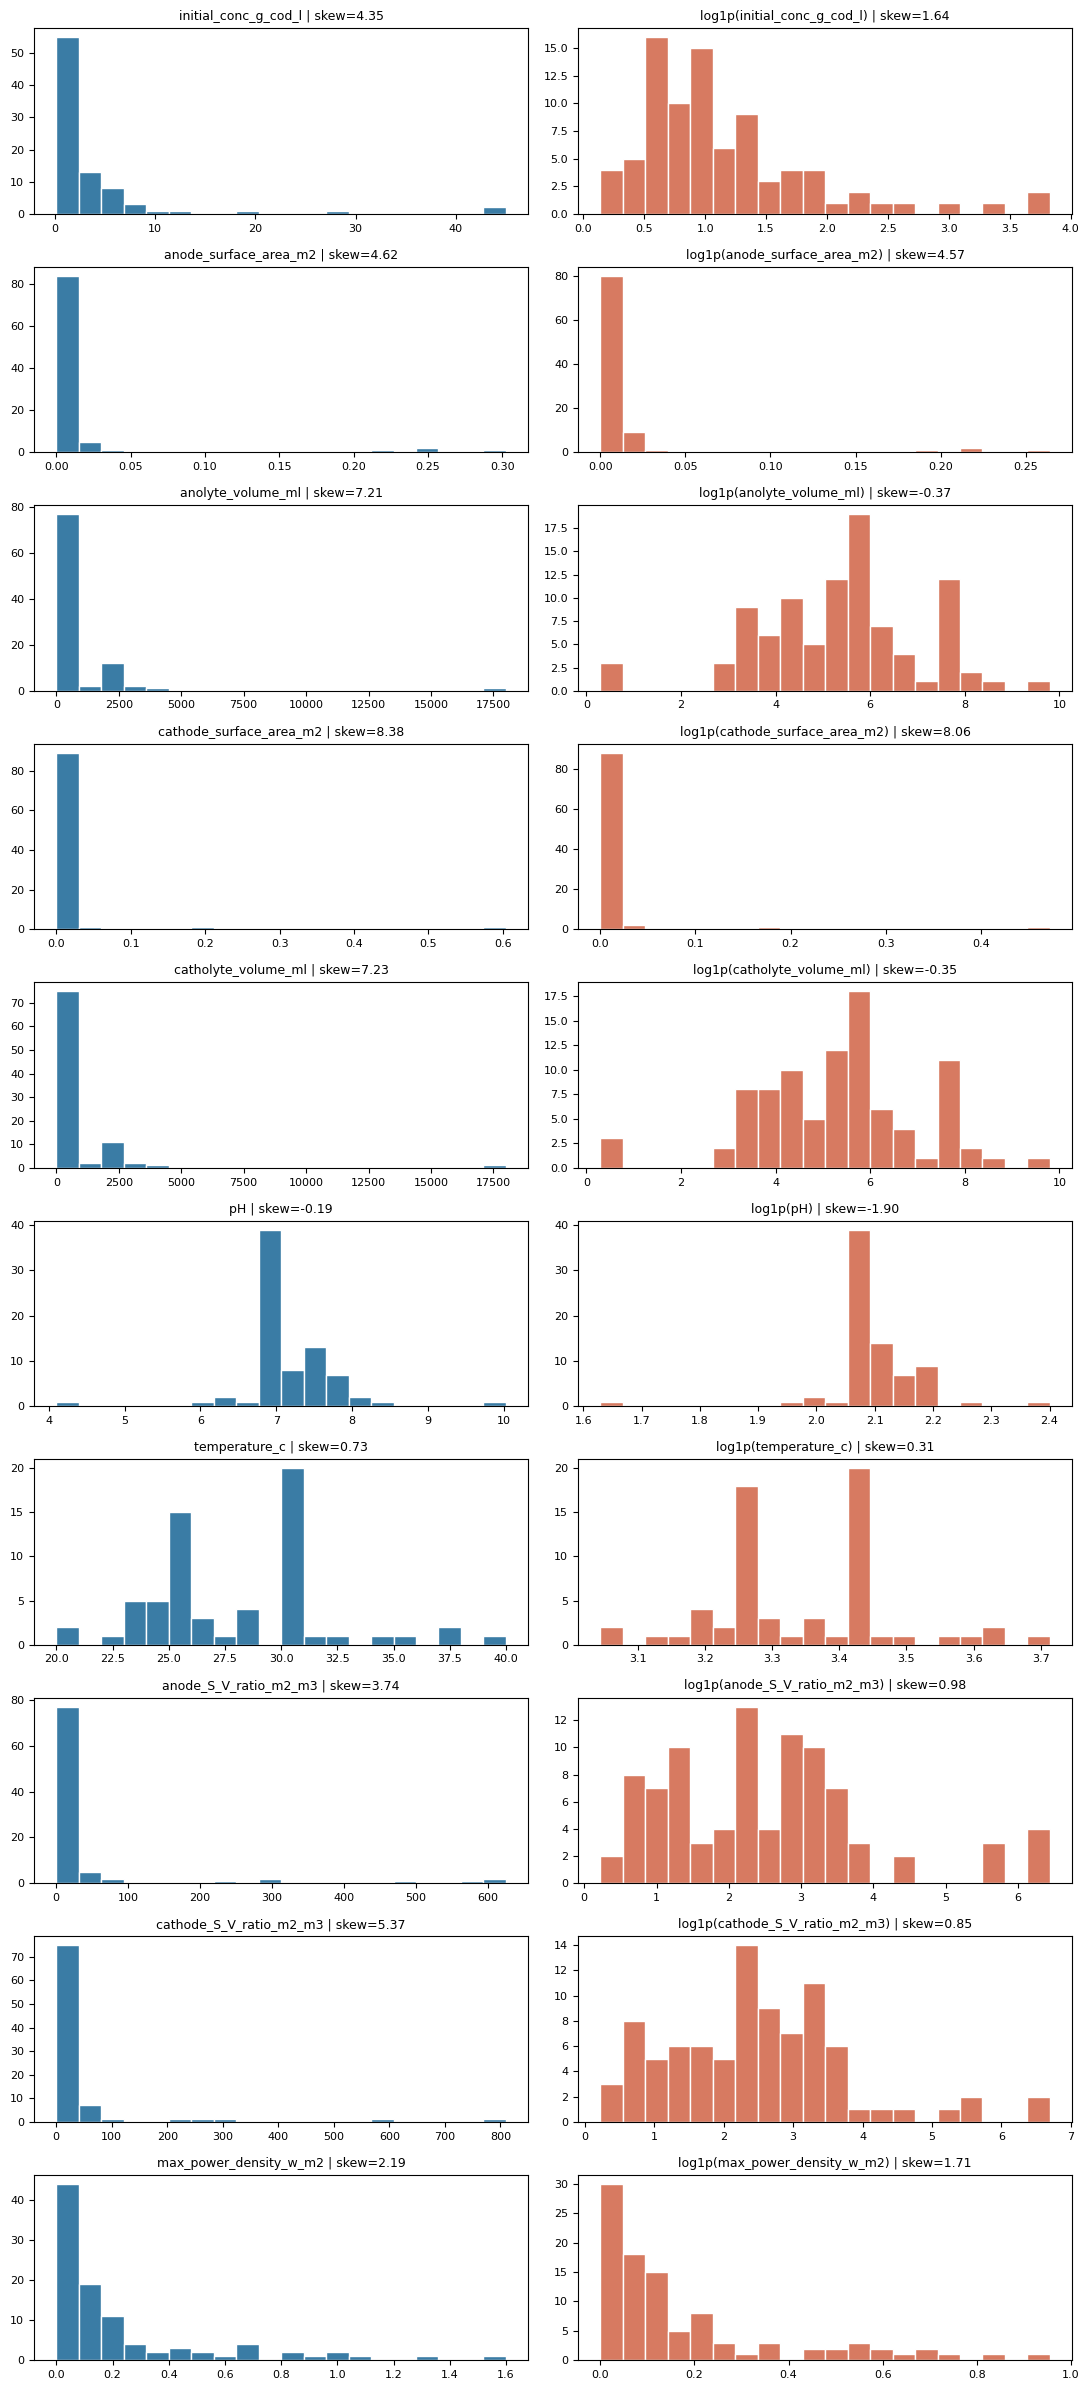

In [29]:
plot_cols = numeric_features + [target_col]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(11, 2.4 * len(plot_cols)))

for row, col in enumerate(plot_cols):
    values = df_dedup[col].dropna().astype(float)
    log_values = np.log1p(values)

    axes[row, 0].hist(values, bins=20, color="#3A7CA5", edgecolor="white")
    axes[row, 0].set_title(f"{col} | skew={values.skew():.2f}", fontsize=9)

    axes[row, 1].hist(log_values, bins=20, color="#D77A61", edgecolor="white")
    axes[row, 1].set_title(f"log1p({col}) | skew={log_values.skew():.2f}", fontsize=9)

for ax in axes.ravel():
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [23]:
feature_cols = text_cols + numeric_features

replicate_summary = (
    df_dedup
    .groupby(feature_cols, dropna=False)
    .agg(
        n_samples=(target_col, "size"),
        n_targets=(target_col, "nunique"),
        target_mean=(target_col, "mean"),
        target_std=(target_col, "std"),
    )
    .reset_index()
)

replicate_summary = replicate_summary[replicate_summary["n_samples"] > 1].copy()
replicate_rows = df_dedup.merge(replicate_summary[feature_cols], on=feature_cols, how="inner")

print(f"Replicate input groups: {len(replicate_summary)}")
print(f"Rows involved: {len(replicate_rows)}")

display(replicate_summary.sort_values(["n_targets", "n_samples"], ascending=False).reset_index(drop=True))
display(replicate_rows.sort_values(feature_cols + [target_col]).reset_index(drop=True))

Replicate input groups: 4
Rows involved: 10


,substrate_type,anode_material,cathode_material,initial_conc_g_cod_l,anode_surface_area_m2,anolyte_volume_ml,cathode_surface_area_m2,catholyte_volume_ml,pH,temperature_c,anode_S_V_ratio_m2_m3,cathode_S_V_ratio_m2_m3,n_samples,n_targets,target_mean,target_std
0,glucose,carbon cloth,carbon felt,1.067,0.0004,40.0,0.000140,40.0,7.42,35.0,10.0,3.500000,4,4,0.632757,0.124900
1,banana peel slurry,activated charcoal on stainless steel mesh,graphite rod,1.366,0.0060,300.0,0.003142,300.0,7.90,NaN,20.0,10.471977,2,2,0.065750,0.029911
2,dried banana peel powder,activated charcoal on stainless steel mesh,graphite rod,1.126,0.0060,300.0,0.003142,300.0,7.50,NaN,20.0,10.471977,2,2,0.001150,0.001485
3,sodium acetate,carbon felt,carbon felt,3.000,0.0030,200.0,0.003000,200.0,NaN,26.0,15.0,15.000000,2,2,0.186667,0.084853


,substrate_type,initial_conc_g_cod_l,anode_material,anode_surface_area_m2,anolyte_volume_ml,cathode_material,cathode_surface_area_m2,catholyte_volume_ml,pH,temperature_c,anode_S_V_ratio_m2_m3,cathode_S_V_ratio_m2_m3,max_power_density_w_m2
0,banana peel slurry,1.366,activated charcoal on stainless steel mesh,0.0060,300.0,graphite rod,0.003142,300.0,7.90,NaN,20.0,10.471977,0.044600
1,banana peel slurry,1.366,activated charcoal on stainless steel mesh,0.0060,300.0,graphite rod,0.003142,300.0,7.90,NaN,20.0,10.471977,0.086900
2,dried banana peel powder,1.126,activated charcoal on stainless steel mesh,0.0060,300.0,graphite rod,0.003142,300.0,7.50,NaN,20.0,10.471977,0.000100
3,dried banana peel powder,1.126,activated charcoal on stainless steel mesh,0.0060,300.0,graphite rod,0.003142,300.0,7.50,NaN,20.0,10.471977,0.002200
4,glucose,1.067,carbon cloth,0.0004,40.0,carbon felt,0.000140,40.0,7.42,35.0,10.0,3.500000,0.495190
5,glucose,1.067,carbon cloth,0.0004,40.0,carbon felt,0.000140,40.0,7.42,35.0,10.0,3.500000,0.576440
6,glucose,1.067,carbon cloth,0.0004,40.0,carbon felt,0.000140,40.0,7.42,35.0,10.0,3.500000,0.675350
7,glucose,1.067,carbon cloth,0.0004,40.0,carbon felt,0.000140,40.0,7.42,35.0,10.0,3.500000,0.784050
8,sodium acetate,3.000,carbon felt,0.0030,200.0,carbon felt,0.003000,200.0,NaN,26.0,15.0,15.000000,0.126667
9,sodium acetate,3.000,carbon felt,0.0030,200.0,carbon felt,0.003000,200.0,NaN,26.0,15.0,15.000000,0.246667


In [24]:
# Resolve same-input replicate groups by target consistency.
# A group is treated as consistent when its target range is small enough:
# target_range <= max(ABS_TARGET_RANGE_TOL, REL_TARGET_RANGE_TOL * abs(target_mean)).
# Consistent groups are collapsed to one representative row with mean target.
# Conflicting groups are removed entirely because same observed input maps to incompatible targets.

ABS_TARGET_RANGE_TOL = 0.10  # W/m2, protects low-target groups from over-penalized relative range
REL_TARGET_RANGE_TOL = 0.30  # 30% of group mean target

original_cols = df_dedup.columns.tolist()
df_before_replicate_resolution = df_dedup.copy()

replicate_work = df_before_replicate_resolution.copy()
replicate_work["_input_group_id"] = replicate_work.groupby(feature_cols, dropna=False).ngroup()

feature_values = (
    replicate_work
    .drop_duplicates("_input_group_id", keep="first")
    [["_input_group_id"] + feature_cols]
    .copy()
)

target_stats = (
    replicate_work
    .groupby("_input_group_id", sort=False)
    .agg(
        n_samples=(target_col, "size"),
        n_targets=(target_col, "nunique"),
        target_min=(target_col, "min"),
        target_max=(target_col, "max"),
        target_mean=(target_col, "mean"),
        target_std=(target_col, "std"),
    )
    .reset_index()
)

replicate_resolution_summary = feature_values.merge(target_stats, on="_input_group_id", how="left")
replicate_resolution_summary["target_range"] = (
    replicate_resolution_summary["target_max"] - replicate_resolution_summary["target_min"]
)
replicate_resolution_summary["relative_range"] = (
    replicate_resolution_summary["target_range"]
    / replicate_resolution_summary["target_mean"].abs().clip(lower=1e-12)
)
replicate_resolution_summary["allowed_range"] = np.maximum(
    ABS_TARGET_RANGE_TOL,
    REL_TARGET_RANGE_TOL * replicate_resolution_summary["target_mean"].abs(),
)
replicate_resolution_summary["resolution_decision"] = np.select(
    [
        replicate_resolution_summary["n_samples"] == 1,
        replicate_resolution_summary["target_range"] <= replicate_resolution_summary["allowed_range"],
    ],
    ["keep_single", "merge_mean_target"],
    default="drop_conflict_group",
)

single_group_ids = set(
    replicate_resolution_summary.loc[
        replicate_resolution_summary["resolution_decision"] == "keep_single", "_input_group_id"
    ]
)
merge_groups = replicate_resolution_summary.loc[
    replicate_resolution_summary["resolution_decision"] == "merge_mean_target"
].copy()
conflict_groups = replicate_resolution_summary.loc[
    replicate_resolution_summary["resolution_decision"] == "drop_conflict_group"
].copy()

single_rows = (
    replicate_work.loc[replicate_work["_input_group_id"].isin(single_group_ids), original_cols]
    .copy()
)
merged_rows = merge_groups[feature_cols].copy()
merged_rows[target_col] = merge_groups["target_mean"].to_numpy()
merged_rows = merged_rows[original_cols]

df_replicate_resolved = pd.concat([single_rows, merged_rows], ignore_index=True)
remaining_same_input_groups = (
    df_replicate_resolved
    .groupby(feature_cols, dropna=False)
    .size()
    .loc[lambda sizes: sizes > 1]
)

print(
    f"Replicate consistency rule: target_range <= "
    f"max({ABS_TARGET_RANGE_TOL}, {REL_TARGET_RANGE_TOL} * abs(target_mean))"
)
print(f"Rows before replicate resolution: {len(df_before_replicate_resolution)}")
print(
    f"Merged consistent replicate groups: {len(merge_groups)} groups, "
    f"{int(merge_groups['n_samples'].sum())} rows -> {len(merge_groups)} rows"
)
print(
    f"Dropped conflicting replicate groups: {len(conflict_groups)} groups, "
    f"{int(conflict_groups['n_samples'].sum())} rows removed"
)
print(f"Rows after replicate resolution: {len(df_replicate_resolved)}")
print(f"Remaining same-input groups: {len(remaining_same_input_groups)}")

if len(remaining_same_input_groups) > 0:
    raise ValueError("Replicate resolution failed: same-input groups remain.")

# Use the resolved dataset for the downstream save and description-mapping cells.
df_dedup = df_replicate_resolved.copy()

display(
    replicate_resolution_summary
    .loc[replicate_resolution_summary["n_samples"] > 1]
    .sort_values(["resolution_decision", "target_range"], ascending=[True, False])
    .reset_index(drop=True)
)

if not conflict_groups.empty:
    display(
        conflict_groups
        .sort_values("target_range", ascending=False)
        .reset_index(drop=True)
    )


Replicate consistency rule: target_range <= max(0.1, 0.3 * abs(target_mean))
Rows before replicate resolution: 106
Merged consistent replicate groups: 2 groups, 4 rows -> 2 rows
Dropped conflicting replicate groups: 2 groups, 6 rows removed
Rows after replicate resolution: 98
Remaining same-input groups: 0


,_input_group_id,substrate_type,anode_material,cathode_material,initial_conc_g_cod_l,anode_surface_area_m2,anolyte_volume_ml,cathode_surface_area_m2,catholyte_volume_ml,pH,...,n_samples,n_targets,target_min,target_max,target_mean,target_std,target_range,relative_range,allowed_range,resolution_decision
0,37,glucose,carbon cloth,carbon felt,1.067,0.0004,40.0,0.000140,40.0,7.42,...,4,4,0.495190,0.784050,0.632757,0.124900,0.28886,0.456510,0.189827,drop_conflict_group
1,67,sodium acetate,carbon felt,carbon felt,3.000,0.0030,200.0,0.003000,200.0,NaN,...,2,2,0.126667,0.246667,0.186667,0.084853,0.12000,0.642857,0.100000,drop_conflict_group
2,14,banana peel slurry,activated charcoal on stainless steel mesh,graphite rod,1.366,0.0060,300.0,0.003142,300.0,7.90,...,2,2,0.044600,0.086900,0.065750,0.029911,0.04230,0.643346,0.100000,merge_mean_target
3,33,dried banana peel powder,activated charcoal on stainless steel mesh,graphite rod,1.126,0.0060,300.0,0.003142,300.0,7.50,...,2,2,0.000100,0.002200,0.001150,0.001485,0.00210,1.826087,0.100000,merge_mean_target


,_input_group_id,substrate_type,anode_material,cathode_material,initial_conc_g_cod_l,anode_surface_area_m2,anolyte_volume_ml,cathode_surface_area_m2,catholyte_volume_ml,pH,...,n_samples,n_targets,target_min,target_max,target_mean,target_std,target_range,relative_range,allowed_range,resolution_decision
0,37,glucose,carbon cloth,carbon felt,1.067,0.0004,40.0,0.00014,40.0,7.42,...,4,4,0.495190,0.784050,0.632757,0.124900,0.28886,0.456510,0.189827,drop_conflict_group
1,67,sodium acetate,carbon felt,carbon felt,3.000,0.0030,200.0,0.00300,200.0,NaN,...,2,2,0.126667,0.246667,0.186667,0.084853,0.12000,0.642857,0.100000,drop_conflict_group


In [27]:
OUTPUT_CSV = DATA_PATH.with_name("MFC_dataset_checked_cleaned.csv")

df_dedup.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Saved cleaned dataset: {OUTPUT_CSV}")
print(f"Shape: {df_dedup.shape[0]} rows x {df_dedup.shape[1]} columns")

Saved cleaned dataset: MFC_dataset_checked_cleaned.csv
Shape: 98 rows x 13 columns


In [28]:
description_df = df_dedup.copy()


missing_report = {}
for text_col, desc_col in description_cols.items():
    keys = description_df[text_col].map(normalize_text)
    # Map descriptions and fill missing/unmatched ones with an empty string
    description_df[desc_col] = keys.map(description_lookup[text_col]).fillna("")

    # Audit for missing/blank descriptions for warning report
    missing_values = sorted(description_df.loc[description_df[desc_col] == "", text_col].unique())
    if missing_values:
        missing_report[text_col] = missing_values

# Print a warning if there are unmatched values, but do not raise an error
if missing_report:
    print("Warning: Some cleaned text values could not be mapped to descriptions (leaving them blank):")
    for text_col, values in missing_report.items():
        print(f"  Missing descriptions for {text_col}:")
        for value in values:
            print(f"    - {value}")

DESCRIPTION_OUTPUT_CSV = DATA_PATH.with_name("MFC_dataset_checked_description_cleaned.csv")
description_df.to_csv(DESCRIPTION_OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"\nDescription reference: {DESCRIPTION_REF}")
print(f"Saved cleaned dataset with descriptions: {DESCRIPTION_OUTPUT_CSV}")
print(f"Shape: {description_df.shape[0]} rows x {description_df.shape[1]} columns")
print(description_df[list(description_cols.values())].isna().sum())


  Missing descriptions for anode_material:
    - palm kernel shell derived graphene oxide
    - palm kernel shell derived reduced graphene oxide
    - silver plate
    - stainless steel brush
  Missing descriptions for cathode_material:
    - biomass-derived activated carbon
    - platinum on vulcan carbon coated carbon cloth
  Missing descriptions for substrate_type:
    - apple waste
    - rotten sweet potatoes
    - vegetable protein

Description reference: C:\Users\shimk\Downloads\BES_061726\unique_descriptions_reference.json
Saved cleaned dataset with descriptions: MFC_dataset_checked_description_cleaned.csv
Shape: 98 rows x 16 columns
anode_description        0
cathode_description      0
substrate_description    0
dtype: int64
